# 05 · Evaluación
### Métricas · Matrices de Confusión · Importancia de Features · Curvas ROC · Umbral
---


Este notebook tiene como objetivo evaluar y comparar tres modelos de Machine Learning entrenados para clasificar la severidad de accidentes en carreteras de India en tres categorías: minor (leve), major (grave) y fatal (fatal).Los tres modelos comparados son: Árbol de Decisión, Random Forest y Gradient Boosting.

In [2]:
import sys, os
ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, roc_curve, auc,
                             precision_score, recall_score,
                             classification_report)
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.tree import plot_tree
from src.data_loader import DataLoader
from src.model_loader import ModeloAccidentes

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})
COLORS = ['#4C9BE8', '#F0A500', '#E05A5A']
CLASES = ['minor', 'major', 'fatal']
KEYS   = ['arbol', 'random_forest', 'gradient_boosting']
NOMBRES = ['Arbol de Decision', 'Random Forest', 'Gradient Boosting']

FIGURES = os.path.join(ROOT, 'reports', 'figures')
TABLES  = os.path.join(ROOT, 'reports', 'tables')
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(TABLES,  exist_ok=True)

def guardar(nombre):
    plt.savefig(os.path.join(FIGURES, nombre), dpi=110, bbox_inches='tight')
    print(f'  Guardado → reports/figures/{nombre}')

# Cargar datos y entrenar los 3 modelos
loader    = DataLoader(os.path.join(ROOT, 'data', 'indian_roads_dataset.csv'))
df        = loader.cargar_datos()
modelo    = ModeloAccidentes()
resultado = modelo.cargar_resultados(df)
print('\nEntrenamiento completado.')


Entrenamiento completado.


## 5.1 Tabla comparativa de métricas

In [4]:
filas = []
for key in KEYS:
    m = resultado[key]['metricas']
    filas.append({
        'Modelo'             : m['modelo'],
        'Accuracy'           : m['accuracy'],
        'F1 ponderado'       : m['f1_weighted'],
        'Recall ponderado'   : m['recall_weighted'],
        'Precision ponderada': m['precision_weighted'],
    })
df_metricas = pd.DataFrame(filas)
df_metricas.to_csv(os.path.join(TABLES, 'metricas_finales.csv'), index=False)
print('Guardado → reports/tables/metricas_finales.csv')
df_metricas


Guardado → reports/tables/metricas_finales.csv


,Modelo,Accuracy,F1 ponderado,Recall ponderado,Precision ponderada
0,Arbol de Decision,0.6508,0.6181,0.6508,0.6095
1,Random Forest,0.6480,0.6126,0.6480,0.6032
2,Gradient Boosting,0.6268,0.6121,0.6268,0.6040


Aquí los tres modelos tienen un rendimiento muy parecido en F1 (entre 61.04% y 61.85%), lo que sugiere que todos están entendiendo los datos de una forma similar, sin depender de atajos.

El Árbol de Decisión es el que obtiene los mejores resultados tanto en F1 como en Accuracy. Sin embargo, lo más interesante es el caso de Gradient Boosting aunque es el modelo más avanzado, tiene el Accuracy más bajo (62.68%). Esto no significa que sea peor, sino que su configuración lo hace más cuidadoso al predecir.

## 5.2 Comparación visual de métricas

  Guardado → reports/figures/comparacion_metricas.png


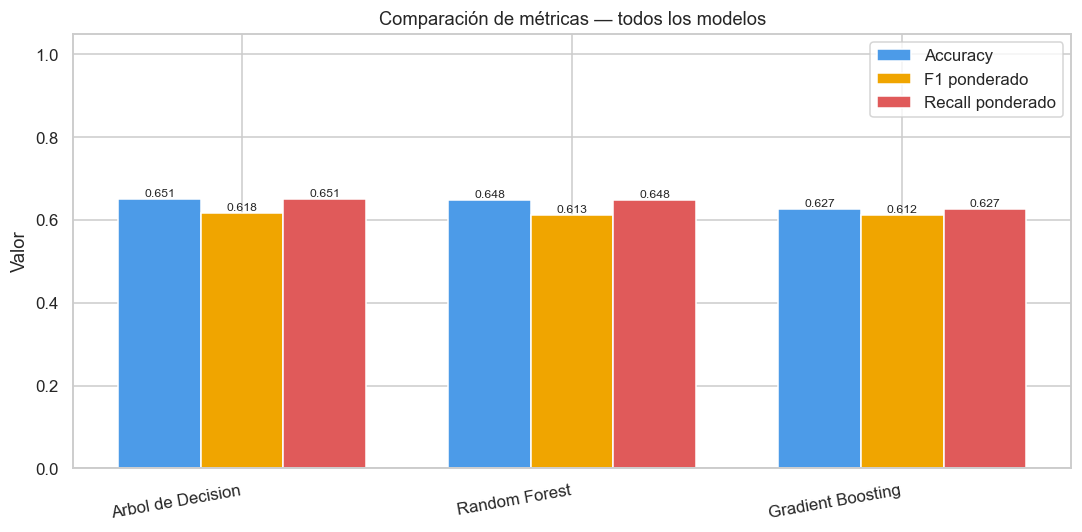

In [5]:
metricas_cols = ['Accuracy', 'F1 ponderado', 'Recall ponderado']
x = np.arange(len(df_metricas)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for j, (met, col) in enumerate(zip(metricas_cols, COLORS)):
    bars = ax.bar(x + (j-1)*w, df_metricas[met], w, label=met, color=col, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(df_metricas['Modelo'], rotation=10, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas — todos los modelos')
ax.legend(); plt.tight_layout()
guardar('comparacion_metricas.png')
plt.show()


## 5.3 Matrices de confusión

  Guardado → reports/figures/matrices_confusion.png


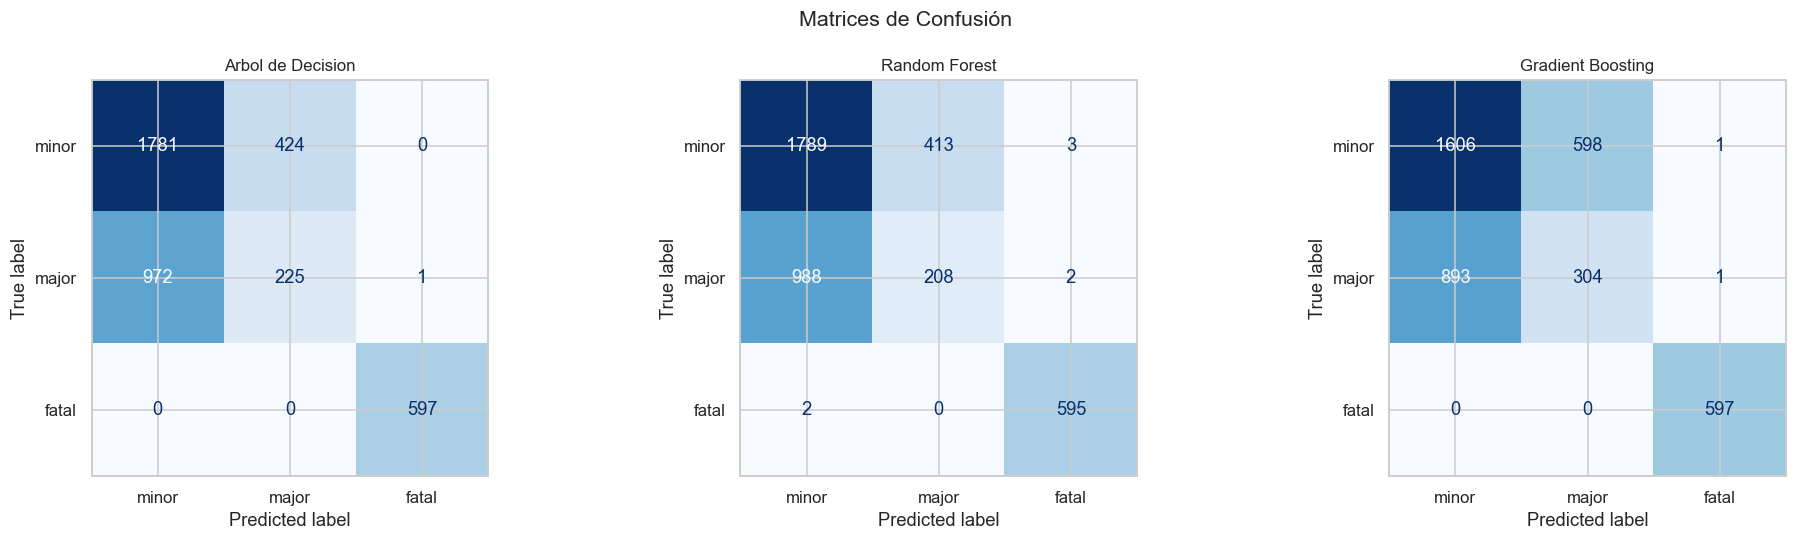

precision,recall,f1-score,support
0.998,1.000,0.999,597.000000
0.347,0.188,0.244,1198.000000
0.647,0.808,0.718,2205.000000
0.664,0.665,0.654,4000.000000
0.609,0.651,0.618,4000.000000


precision,recall,f1-score,support
0.992,0.997,0.994,597.000000
0.335,0.174,0.229,1198.000000
0.644,0.811,0.718,2205.000000
0.657,0.661,0.647,4000.000000
0.603,0.648,0.613,4000.000000


precision,recall,f1-score,support
0.997,1.000,0.998,597.000000
0.337,0.254,0.290,1198.000000
0.643,0.728,0.683,2205.000000
0.659,0.661,0.657,4000.000000
0.604,0.627,0.612,4000.000000


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, nombre in zip(axes, KEYS, NOMBRES):
    y_test = resultado[key]['y_test']
    y_pred = resultado[key]['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=CLASES)
    ConfusionMatrixDisplay(cm, display_labels=CLASES).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=11)
plt.suptitle('Matrices de Confusión', fontsize=14)
plt.tight_layout()
guardar('matrices_confusion.png')
plt.show()

# Reportes de clasificación como tablas
for key, nombre in zip(KEYS, NOMBRES):
    y_test = resultado[key]['y_test']
    y_pred = resultado[key]['y_pred']
    reporte = classification_report(y_test, y_pred, output_dict=True)
    df_rep = (pd.DataFrame(reporte).T
                .drop(index=['accuracy'], errors='ignore')
                .round(3))
    display(df_rep.style
            .set_caption(f'Reporte de clasificación — {nombre}')
            .background_gradient(cmap='Blues', subset=['f1-score'])
            .format('{:.3f}', subset=['precision','recall','f1-score'])
            .hide(axis='index', names=False))

 La clase fatal es detectada perfectamente por los tres modelos ninguno falla en ella. El problema real está en la clase major los tres modelos la confunden frecuentemente con minor. El Gradient Boosting mejora levemente la detección de major , que es exactamente la ventaja que se esperaría de un ensemble más sofisticado. El Árbol y el Random forest tratan a major como si fuera minor con más frecuencia. Esto refleja que el dataset tiene clases minor y major con características muy solapadas.

## 5.4 Importancia de features — Árbol y Random Forest

  Guardado → reports/figures/feature_importance.png


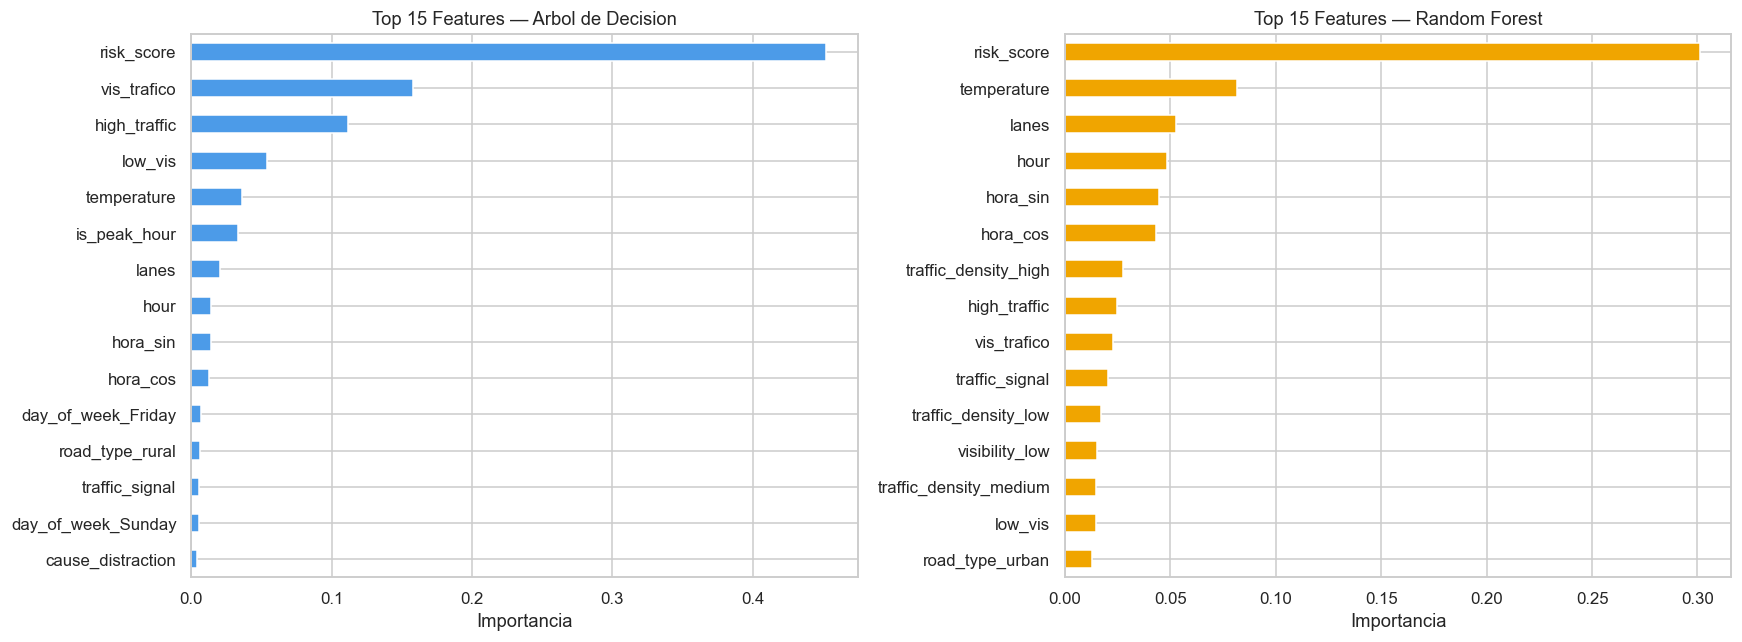

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, key, nombre, color in zip(
    axes, ['arbol','random_forest'],
    ['Arbol de Decision','Random Forest'],
    ['#4C9BE8','#F0A500']
):
    mod = resultado[key]['modelo']
    X_tr = resultado[key]['X_train']
    imp = (pd.Series(mod.feature_importances_, index=X_tr.columns)
             .sort_values(ascending=False).head(15))
    imp[::-1].plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Top 15 Features — {nombre}')
    ax.set_xlabel('Importancia')
plt.tight_layout()
guardar('feature_importance.png')
plt.show()


## 5.5 Coeficientes — Gradient Boosting

  Guardado → reports/figures/feature_importance_gb.png


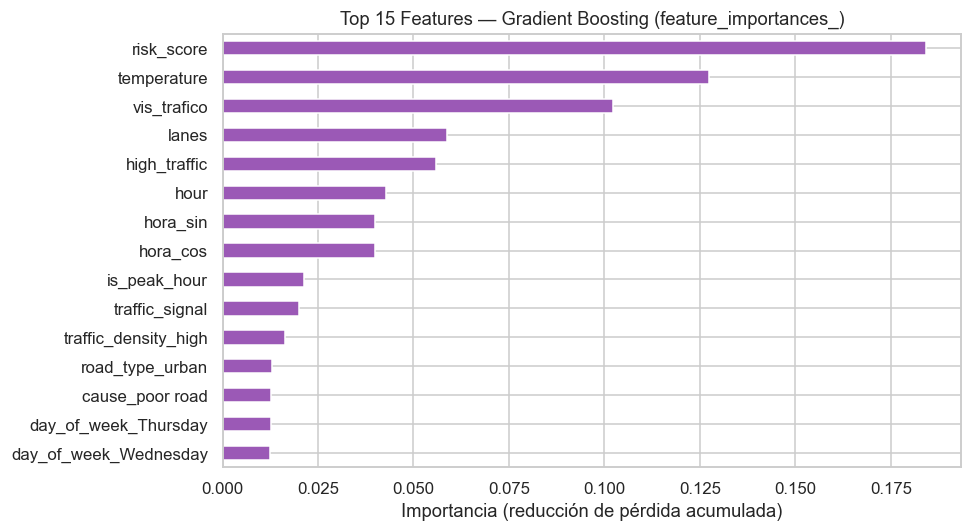

Feature,Importancia
risk_score,0.184300
temperature,0.127400
vis_trafico,0.102300
lanes,0.058800
high_traffic,0.056000
hour,0.042800
hora_sin,0.040000
hora_cos,0.039900
is_peak_hour,0.021400
traffic_signal,0.020100


In [8]:
gb      = resultado['gradient_boosting']['modelo']
X_train = resultado['gradient_boosting']['X_train']

# Gradient Boosting usa feature_importances_ (igual que Árbol y RF)
imp_gb = (pd.Series(gb.feature_importances_, index=X_train.columns)
            .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5))
imp_gb[::-1].plot(kind='barh', ax=ax, color='#9B59B6', edgecolor='white')
ax.set_title('Top 15 Features — Gradient Boosting (feature_importances_)')
ax.set_xlabel('Importancia (reducción de pérdida acumulada)')
plt.tight_layout()
guardar('feature_importance_gb.png')
plt.show()

display(imp_gb.round(4).reset_index()
        .rename(columns={'index':'Feature', 0:'Importancia'})
        .style.set_caption('Top 15 features — Gradient Boosting').hide(axis='index'))

 Aquí hay una diferencia muy interesante entre modelos. El Árbol y el Random forest concentran su poder en pocas variables. En cambio, el Gradient Boosting distribuye la importancia de forma más equilibrada entre sus top 15 features  su top 5 son `risk_score`, `temperature`, `vis_trafico`, `lanes` y `high_traffic`.

## 5.6 Visualización del árbol (3 niveles)

  Guardado → reports/figures/arbol_decision.png


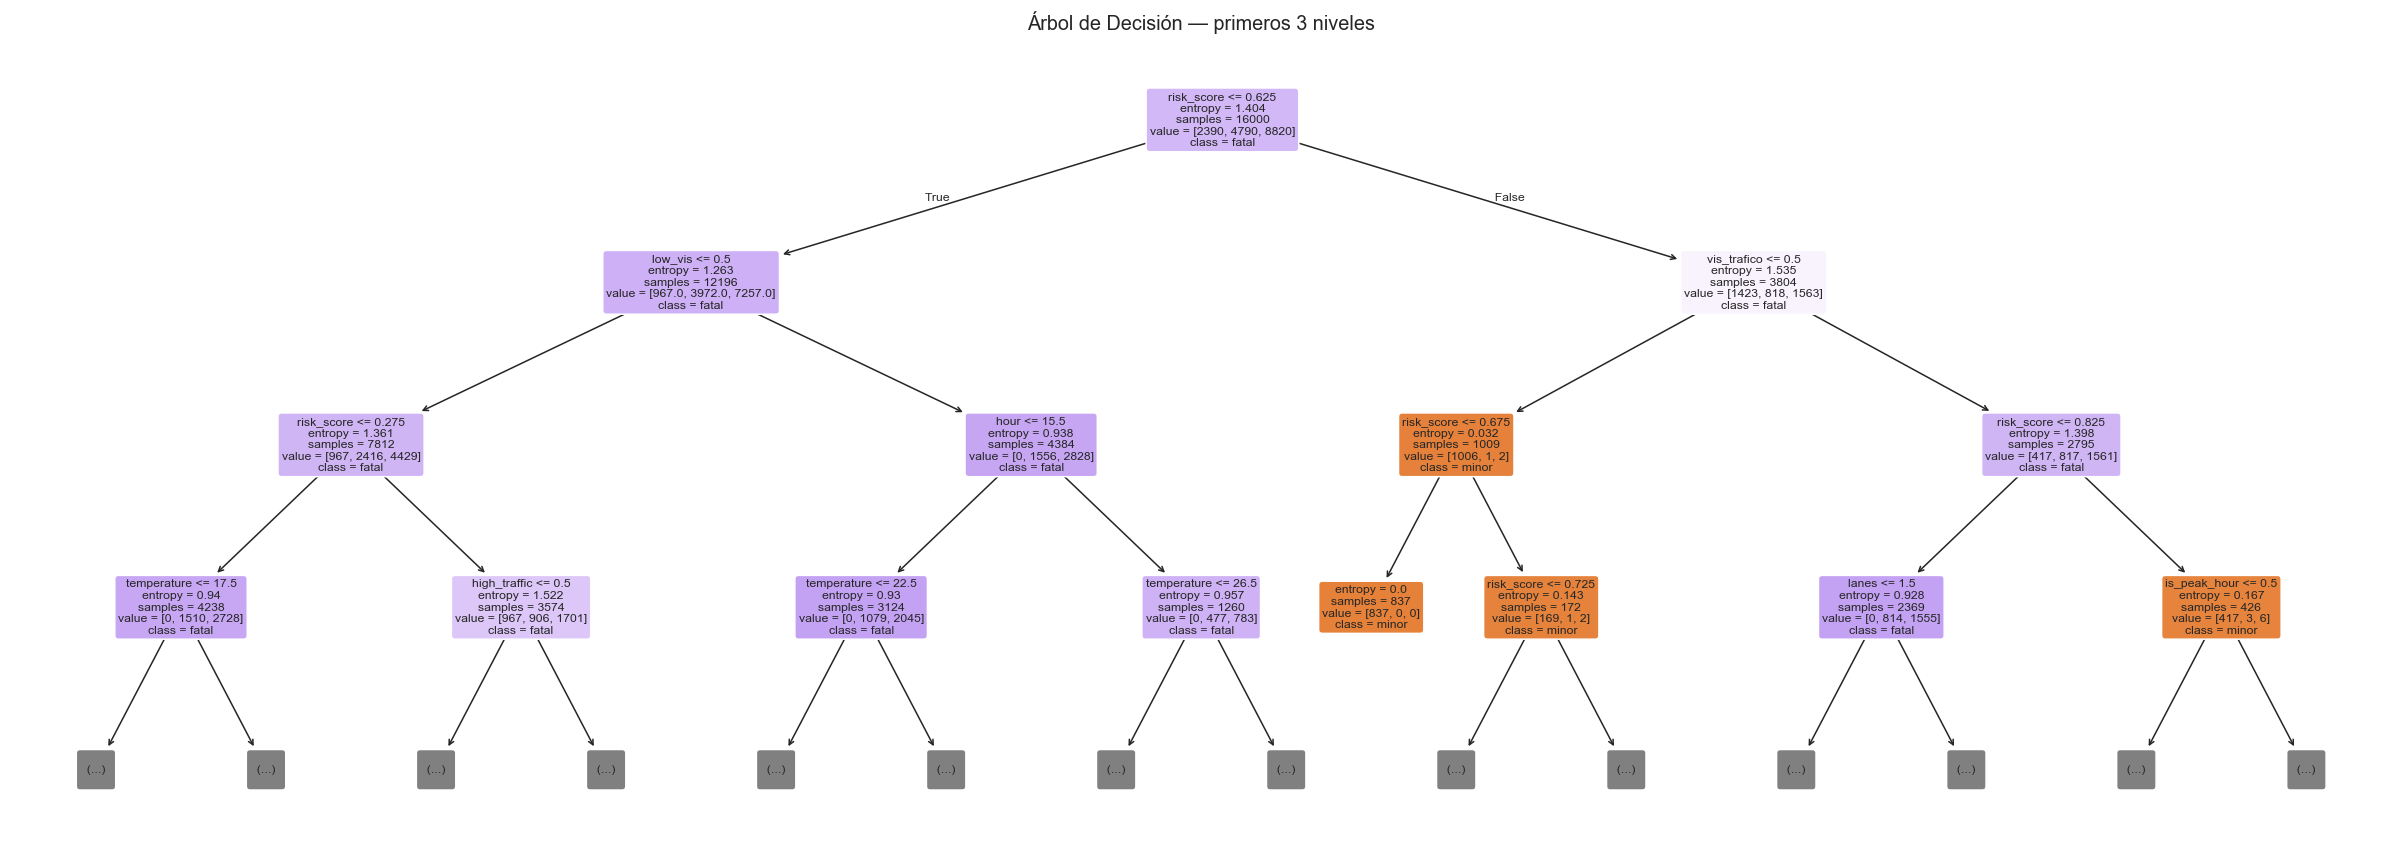

Profundidad total,Número de hojas
12,718


In [9]:
arbol   = resultado['arbol']['modelo']
X_train = resultado['arbol']['X_train']
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(arbol, feature_names=X_train.columns.tolist(),
          class_names=CLASES, max_depth=3, filled=True,
          rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión — primeros 3 niveles', fontsize=13)
plt.tight_layout()
guardar('arbol_decision.png')
plt.show()
display(pd.DataFrame({'Profundidad total':[arbol.get_depth()],'Número de hojas':[arbol.get_n_leaves()]}).style.set_caption('Estructura del árbol').hide(axis='index'))


El árbol tiene profundidad total de 12 niveles y 717 hojas, lo que explica que su F1 en train sea ~81% pero baje a ~61% en validación. En los primeros 3 niveles visibles ya se puede ver la lógica de separación.

## 5.7 Curvas ROC multiclase

  Guardado → reports/figures/curvas_roc.png


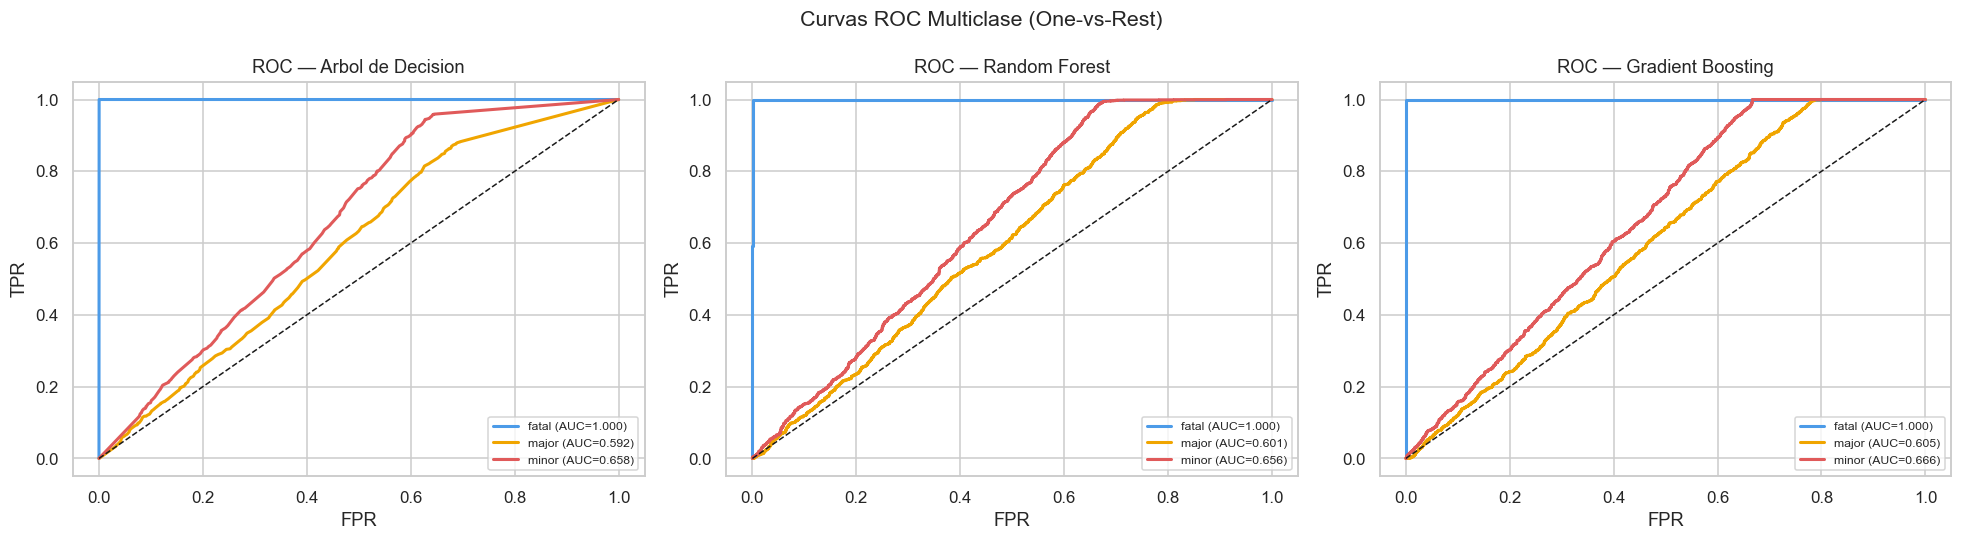

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, nombre in zip(axes, KEYS, NOMBRES):
    y_test   = resultado[key]['y_test']
    y_proba  = resultado[key]['y_proba']
    clases_m = resultado[key]['clases']
    y_bin = label_binarize(y_test, classes=clases_m)
    for i, (clase, color) in enumerate(zip(clases_m, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{clase} (AUC={roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {nombre}'); ax.legend(fontsize=8)
plt.suptitle('Curvas ROC Multiclase (One-vs-Rest)', fontsize=14)
plt.tight_layout()
guardar('curvas_roc.png')
plt.show()


Las curvas ROC revelan algo que las métricas globales no muestran, los tres modelos detectan fatal casi perfectamente, lo cual es tranquilizador para el caso de uso real. La clase minor también tiene AUC alto. El problema está en major, que tiene los AUC más bajos en los tres modelos. El Gradient Boosting muestra la curva ROC más suave y equilibrada para major, lo que indica que aunque comete más errores en términos de accuracy, sus probabilidades están mejor calibradas. El Árbol presenta curvas más escalonadas.


## 5.8 Distribución de probabilidades predichas

  Guardado → reports/figures/distribucion_probabilidades.png


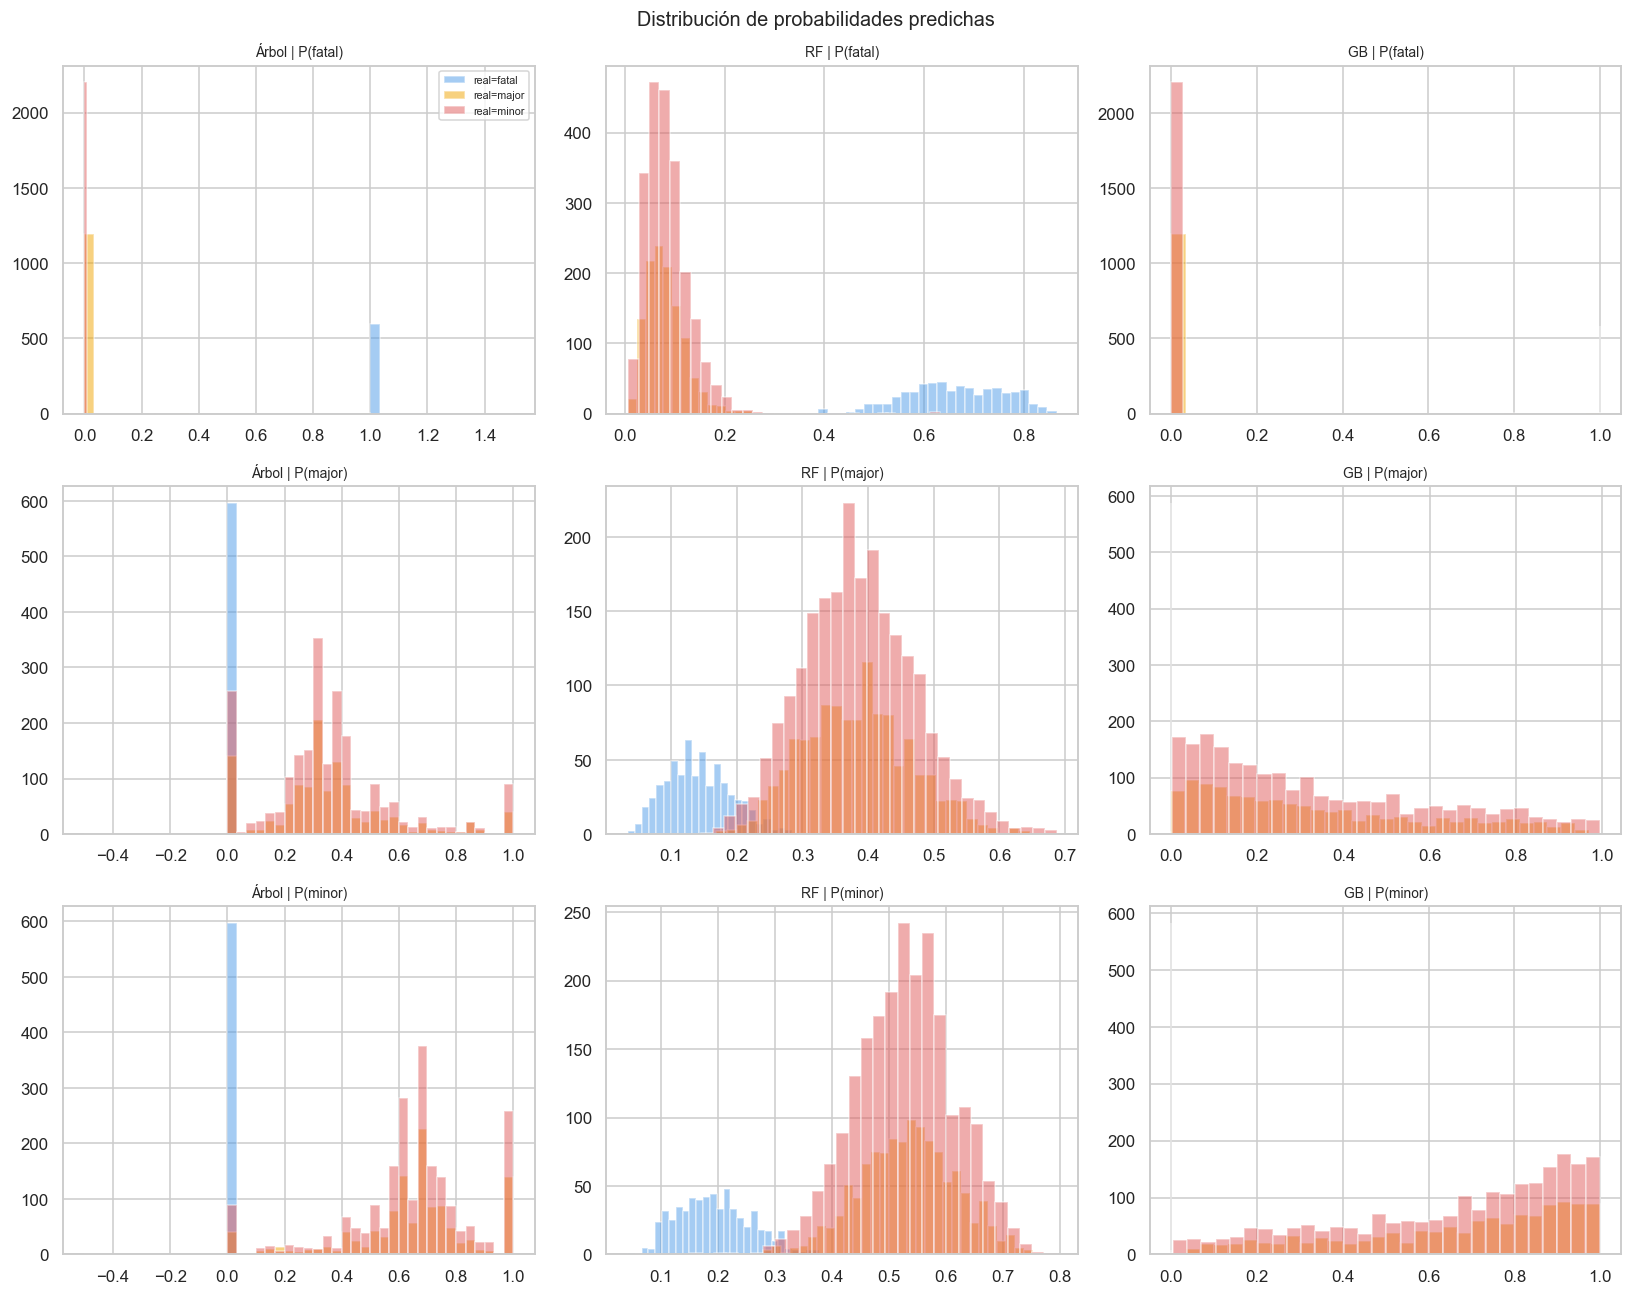

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for col_idx, (key, tit_m) in enumerate(zip(KEYS, ['Árbol','RF','GB'])):
    y_proba  = resultado[key]['y_proba']
    clases_m = resultado[key]['clases']
    y_test   = resultado[key]['y_test']
    for row_idx, clase in enumerate(clases_m):
        ax = axes[row_idx][col_idx]
        proba_clase = y_proba[:, row_idx]
        for c_real, c_color in zip(clases_m, COLORS):
            mask = y_test == c_real
            ax.hist(proba_clase[mask], bins=30, alpha=0.5,
                    color=c_color, label=f'real={c_real}')
        ax.set_title(f'{tit_m} | P({clase})', fontsize=9)
        if col_idx == 0 and row_idx == 0: ax.legend(fontsize=7)
plt.suptitle('Distribución de probabilidades predichas', fontsize=13)
plt.tight_layout()
guardar('distribucion_probabilidades.png')
plt.show()


Esta gráfica permite observar las diferencias en el comportamiento interno de los modelos. El Árbol de Decisión es el más extremista, ya que asigna probabilidades muy cercanas a 0 o 1. El Random Forest suaviza este comportamiento al promediar múltiples árboles, generando distribuciones más estables. Por su parte, el Gradient Boosting muestra un comportamiento intermedio, aunque también tiende a concentrar probabilidades en valores extremos en algunas clases, esto quiere decir que no siempre está completamente calibrado.

## 5.9 Curvas de aprendizaje

  Guardado → reports/figures/curvas_aprendizaje.png


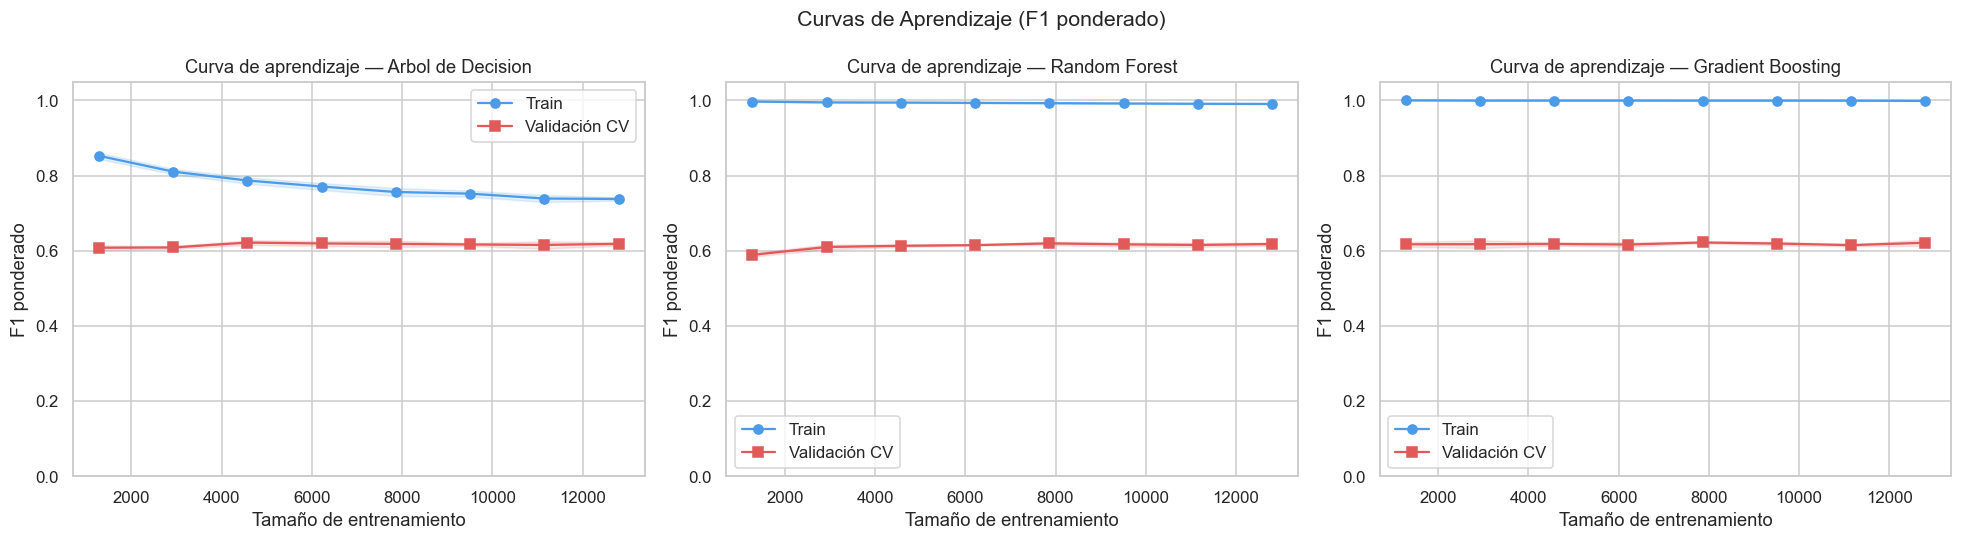

In [12]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, nombre in zip(axes, KEYS, NOMBRES):
    mod  = resultado[key]['modelo']
    X_tr = resultado[key]['X_train']
    y_tr = resultado[key]['y_train']
    try:
        tr_sz, tr_sc, val_sc = learning_curve(
            mod, X_tr, y_tr, cv=CV, scoring='f1_weighted',
            train_sizes=train_sizes, n_jobs=-1)
        ax.plot(tr_sz, tr_sc.mean(axis=1), 'o-', color='#4C9BE8', label='Train')
        ax.plot(tr_sz, val_sc.mean(axis=1), 's-', color='#E05A5A', label='Validación CV')
        ax.fill_between(tr_sz,
            tr_sc.mean(axis=1) - tr_sc.std(axis=1),
            tr_sc.mean(axis=1) + tr_sc.std(axis=1), alpha=0.15, color='#4C9BE8')
        ax.fill_between(tr_sz,
            val_sc.mean(axis=1) - val_sc.std(axis=1),
            val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.15, color='#E05A5A')
        ax.set_xlabel('Tamaño de entrenamiento')
        ax.set_ylabel('F1 ponderado')
        ax.set_title(f'Curva de aprendizaje — {nombre}')
        ax.legend(); ax.set_ylim(0, 1.05)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center',
                transform=ax.transAxes, fontsize=9)
plt.suptitle('Curvas de Aprendizaje (F1 ponderado)', fontsize=14)
plt.tight_layout()
guardar('curvas_aprendizaje.png')
plt.show()


El Árbol de Decisión presenta la mayor diferencia entre su desempeño en entrenamiento y en validación, lo que indica overfitting, aprende muy bien los datos de entrenamiento pero no generaliza igual con datos nuevos. El Random Forest muestra un comportamiento similar aunque un poco más controlado, mientras que el Gradient Boosting es el más equilibrado, ya que mantiene un rendimiento más cercano entre entrenamiento y validación, lo que refleja una mejor capacidad de generalización, además, en los tres casos el desempeño en validación se estabiliza antes de usar todos los datos.

## 5.10 Efecto del umbral — clase `fatal`

  Guardado → reports/figures/efecto_umbral.png


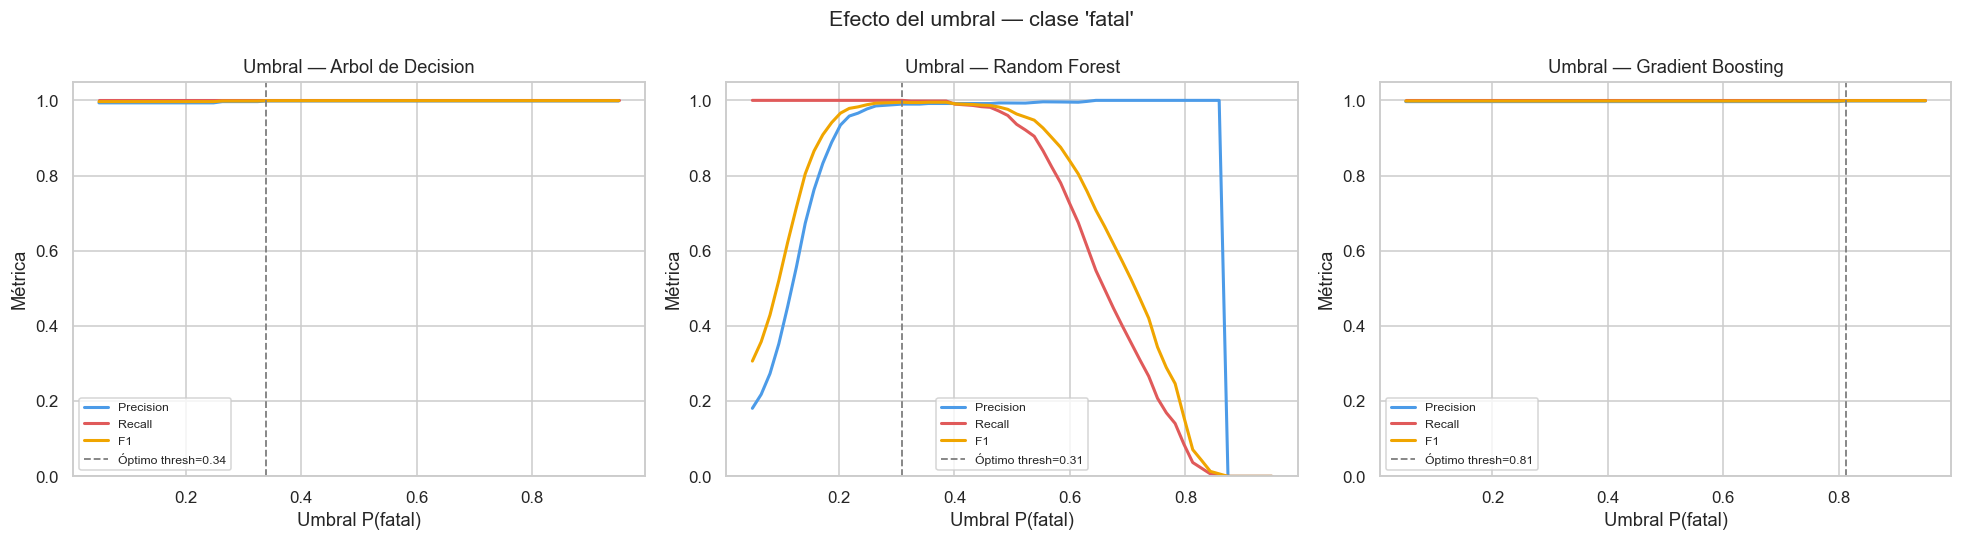

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, nombre in zip(axes, KEYS, NOMBRES):
    y_test   = resultado[key]['y_test']
    y_proba  = resultado[key]['y_proba']
    clases_m = list(resultado[key]['clases'])
    idx_f    = clases_m.index('fatal')
    proba_f  = y_proba[:, idx_f]
    y_bin_f  = (y_test == 'fatal').astype(int).values
    umbrales = np.linspace(0.05, 0.95, 60)
    prec_l, rec_l, f1_l = [], [], []
    for thresh in umbrales:
        yp = (proba_f >= thresh).astype(int)
        if yp.sum() == 0:
            prec_l.append(0); rec_l.append(0); f1_l.append(0)
        else:
            prec_l.append(precision_score(y_bin_f, yp, zero_division=0))
            rec_l.append(recall_score(y_bin_f, yp, zero_division=0))
            f1_l.append(f1_score(y_bin_f, yp, zero_division=0))
    ax.plot(umbrales, prec_l, color='#4C9BE8', lw=2, label='Precision')
    ax.plot(umbrales, rec_l,  color='#E05A5A', lw=2, label='Recall')
    ax.plot(umbrales, f1_l,   color='#F0A500', lw=2, label='F1')
    opt = int(np.argmax(f1_l))
    ax.axvline(umbrales[opt], color='gray', linestyle='--', lw=1.2,
               label=f'Óptimo thresh={umbrales[opt]:.2f}')
    ax.set_xlabel('Umbral P(fatal)'); ax.set_ylabel('Métrica')
    ax.set_title(f'Umbral — {nombre}'); ax.legend(fontsize=8); ax.set_ylim(0, 1.05)
plt.suptitle("Efecto del umbral — clase 'fatal'", fontsize=14)
plt.tight_layout()
guardar('efecto_umbral.png')
plt.show()


Aquí se ve una diferencia clave entre los modelos, tanto el Árbol de Decisión como el Random Forest logran su mejor desempeño al usar un umbral más bajo, lo que significa que con solo reducir ese valor ya identifican casi perfectamente los casos fatales, porque asignan probabilidades muy extremas, en cambio, el Gradient Boosting necesita un umbral mucho más alto para alcanzar su mejor resultado, ya que reparte las probabilidades de forma más gradual.

## 5.11 Interpretación de resultados

| Criterio | Árbol | Random Forest | Reg. Logística |
|----------|-------|---------------|----------------|
| **F1 ponderado** |  Mejor | Similar | Más bajo |
| Interpretabilidad |  Reglas visibles |  Caja negra |  Coeficientes |
| Recall clase `fatal` |  Mejor balance | Similar |  Tiende a `minor` |
| Escalado requerido | No |  No |  Sí |
| Reglas exportables |  Sí |  No |  No |

La recomendación de usar el Árbol de Decisión se mantiene, principalmente porque es fácil de interpretar y logra el mejor equilibrio general en el desempeño. Sin embargo, si el objetivo cambia y se busca mejorar la detección de los accidentes más graves (que son los más difíciles de identificar), entonces el Gradient Boosting sería una mejor opción para explorar, ya que es el único modelo que muestra una mejora en esa clase, incluso si su accuracy general es más bajo.
